# Extended Lab: Cross-Correlation, ARIMAX, and VAR — SOLUTIONS

This is the fully worked version of `01_extended_lab_skeleton.ipynb`, based on
Chapter 12 ("Multivariate Time Series") of *Building Statistical Models in
Python*, extended with train/test evaluation, multicollinearity checks
(VIF), Granger causality, impulse response functions, and a rolling-origin
backtest sketch. See `00_theory_and_background.md` for the theory behind
every step.

**Data note:** the original chapter uses the UCI "Beijing PM2.5" weather
dataset, downloaded from `archive.ics.uci.edu`. To keep this notebook
runnable anywhere (including offline/sandboxed environments), Part 1 uses a
**synthetic weather-like dataset** generated with the same qualitative
structure (daily seasonality, and wind speed driven by specific lags of
temperature/pressure/dew point) — so the cross-correlation and ARIMAX steps
behave the way the book describes, and you can verify your CCF plots
against ground truth. A commented-out block shows how to swap in the real
UCI data if you have internet access.

Part 2 uses `statsmodels`' built-in US macroeconomic dataset (no download
required at all), matching the book's VAR example.


## Part 0 — Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.signal import correlate
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.statespace.varmax import VARMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import mean_squared_error

import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10, 4)

### Synthetic weather dataset

We build `TEMP`, `PRES`, `DEWP`, `RAIN`, `WSPM` so that wind speed (`WSPM`)
is driven by specific lags of the other three, plus daily seasonality —
exactly the structure the book's CCF/ARIMAX analysis is designed to find.

```python
# --- To use the REAL UCI data instead (requires internet access), do this: ---
# import requests, zipfile
# url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00501/PRSA2017_Data_20130301-20170228.zip'
# r = requests.get(url)
# with open('data.zip', 'wb') as f: f.write(r.content)
# with zipfile.ZipFile('data.zip') as z: z.extractall('./')
# df = pd.read_csv('./PRSA_Data_20130301-20170228/PRSA_Data_Aotizhongxin_20130301-20170228.csv')
# df = df.fillna(method='ffill')
```


In [2]:
def generate_weather_like_data(n=1500, seed=42):
    """Synthetic hourly weather data with known cross-correlation structure,
    used as a stand-in for the UCI Beijing PM2.5 weather dataset."""
    rng = np.random.default_rng(seed)
    t = np.arange(n)

    temp_noise = np.zeros(n)
    for i in range(1, n):
        temp_noise[i] = 0.6 * temp_noise[i-1] + rng.normal(0, 1.0)
    TEMP = 10 + 8*np.sin(2*np.pi*t/24 - 1.2) + 0.002*t + temp_noise

    pres_noise = np.zeros(n)
    for i in range(1, n):
        pres_noise[i] = 0.7 * pres_noise[i-1] + rng.normal(0, 0.8)
    PRES = 1015 - 0.01*np.roll(TEMP, 14) + 3*np.sin(2*np.pi*t/300) + pres_noise
    PRES[:14] = 1015 + pres_noise[:14]

    dewp_noise = np.zeros(n)
    for i in range(1, n):
        dewp_noise[i] = 0.5 * dewp_noise[i-1] + rng.normal(0, 1.2)
    DEWP = -5 + 0.9*np.roll(TEMP, 2) + dewp_noise
    DEWP[:2] = -5 + dewp_noise[:2]

    wspm_noise = np.zeros(n)
    for i in range(2, n):
        wspm_noise[i] = 0.35*wspm_noise[i-1] + 0.15*wspm_noise[i-2] + rng.normal(0, 0.6)

    def lag(arr, k):
        out = np.roll(arr, k)
        out[:k] = arr[0]
        return out

    WSPM = (2.2
            + 0.05*lag(TEMP, 13) - 0.03*lag(TEMP, 24) + 0.04*lag(TEMP, 37)
            - 0.02*lag(PRES-1015, 14) + 0.015*lag(PRES-1015, 37)
            - 0.03*lag(DEWP, 2) + 0.02*lag(DEWP, 20)
            + wspm_noise)
    WSPM = np.clip(WSPM, 0.05, None)

    RAIN = np.clip(rng.exponential(0.15, n) * (rng.random(n) < 0.08), 0, None)

    return pd.DataFrame({"TEMP": TEMP, "PRES": PRES, "DEWP": DEWP, "RAIN": RAIN, "WSPM": WSPM})

df = generate_weather_like_data()
df.head()

,TEMP,PRES,DEWP,RAIN,WSPM
0,2.543687,1015.000000,-5.000000,0.0,2.402621
1,3.854753,1014.054817,-4.016663,0.0,2.402621
2,4.138921,1013.885336,-2.619958,0.0,1.111202
3,7.019555,1013.720052,0.013467,0.0,2.065377
4,9.872592,1015.164154,0.322354,0.0,1.729668


## Part 1 — Cross-correlation & ARIMAX (wind speed forecasting)

### 1.1 Exploratory look at the target series (WSPM)

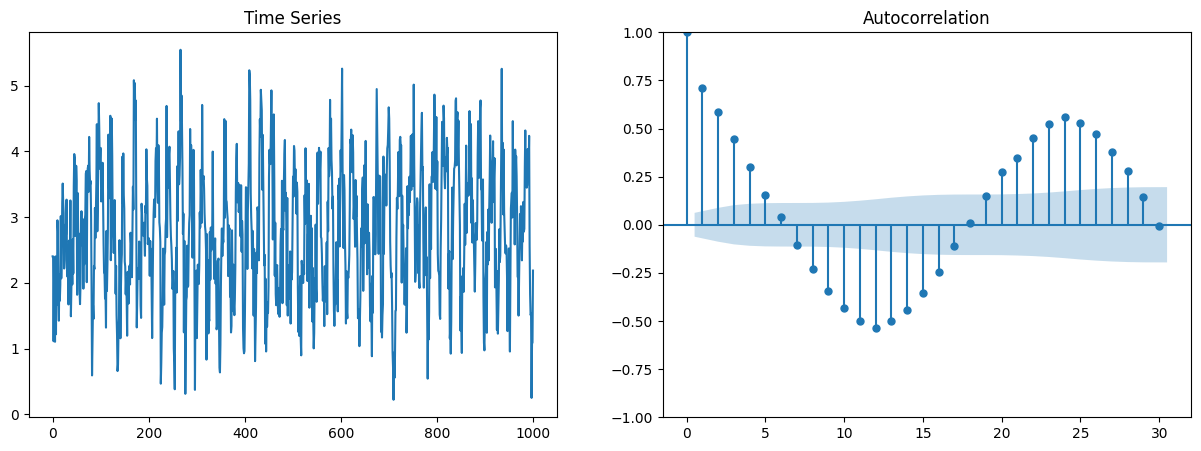

In [3]:
size = 1000
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
ax[0].plot(df.WSPM.iloc[:size])
ax[0].set_title("Time Series")
sm.graphics.tsa.plot_acf(df.WSPM.iloc[:size], ax=ax[1])
plt.show()

The ACF shows fast initial decay (no strong ARIMA-type persistence) but a
bump reappearing around lag 24 — a hint of the daily seasonality baked into
this data, consistent with the book's finding for the real dataset.

### 1.2 The other candidate covariates

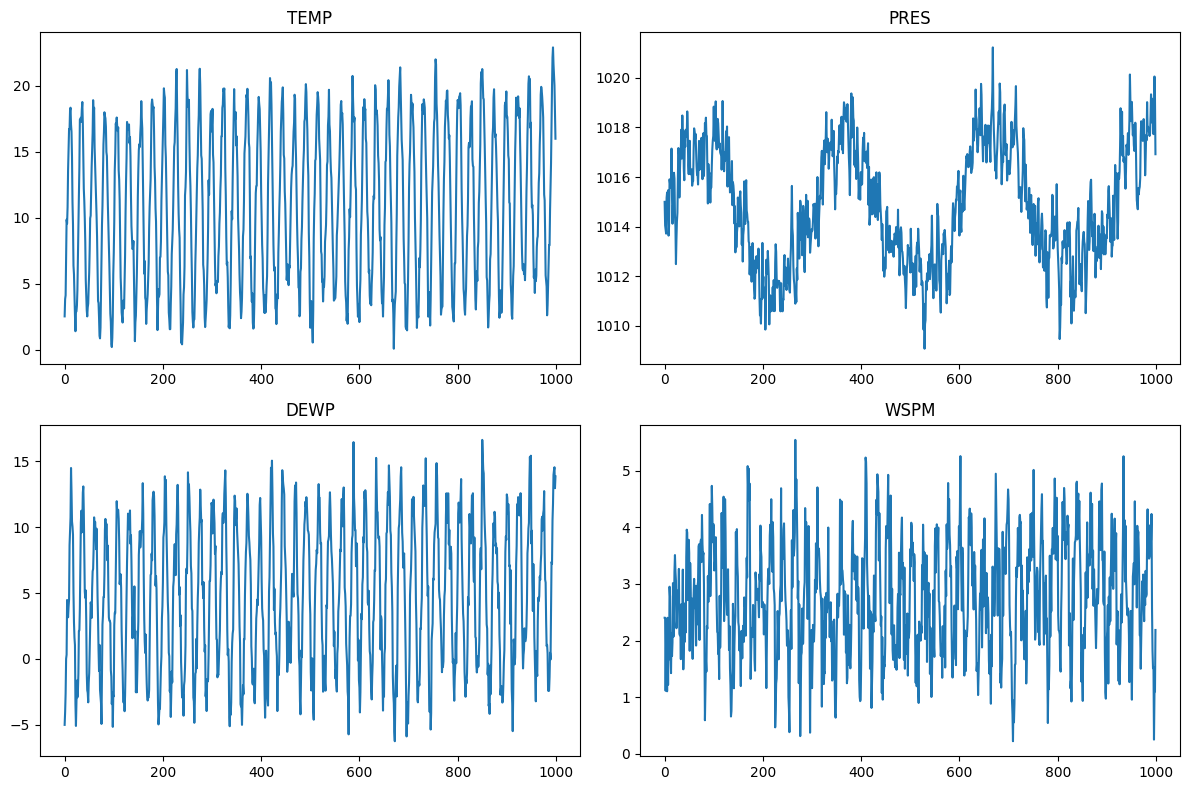

In [4]:
data_cols = ["TEMP", "PRES", "DEWP", "WSPM"]
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
for idx, series in enumerate(data_cols):
    ax_ = ax[idx // 2, idx % 2]
    ax_.set_title(series)
    df[series].iloc[:size].plot(ax=ax_)
plt.tight_layout(); plt.show()

### 1.3 Cross-correlation function (from scratch, matching the book's definition)

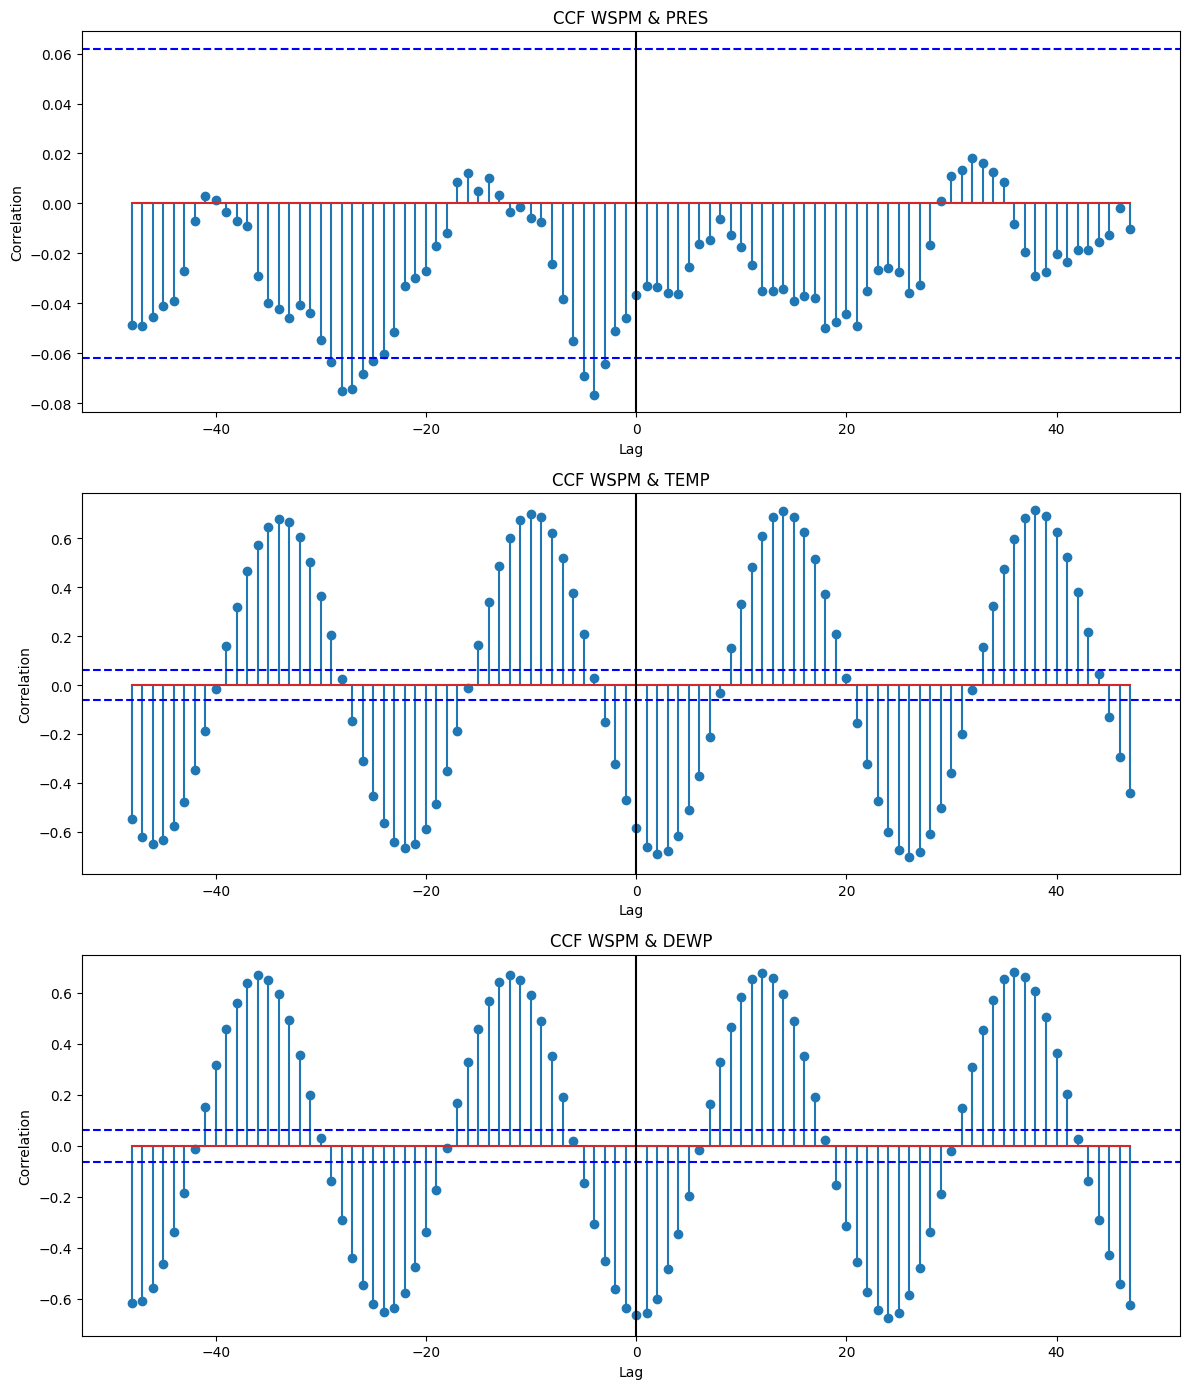

In [5]:
def plot_ccf(data_a, data_b, lag_lookback, percentile, ax, title=None):
    n = len(data_a)
    ccf = correlate(data_a - np.mean(data_a), data_b - np.mean(data_b),
                     method="direct") / (np.std(data_a) * np.std(data_b) * n)
    mid = (len(ccf) - 1) // 2
    lags = np.arange(-lag_lookback, lag_lookback)
    vals = ccf[mid - lag_lookback: mid + lag_lookback]
    zscore = {90: 1.645, 95: 1.96, 99: 2.576}[percentile]
    band = zscore / np.sqrt(n)
    ax.stem(lags, vals, markerfmt="o")
    ax.axhline(band, color="b", ls="--")
    ax.axhline(-band, color="b", ls="--")
    ax.axvline(0, color="black")
    ax.set_title(title); ax.set_xlabel("Lag"); ax.set_ylabel("Correlation")
    return lags, vals, band

fig, ax = plt.subplots(3, 1, figsize=(12, 14))
plot_ccf(df.WSPM.iloc[:size], df.PRES.iloc[:size], 48, 95, ax[0], "CCF WSPM & PRES")
plot_ccf(df.WSPM.iloc[:size], df.TEMP.iloc[:size], 48, 95, ax[1], "CCF WSPM & TEMP")
plot_ccf(df.WSPM.iloc[:size], df.DEWP.iloc[:size], 48, 95, ax[2], "CCF WSPM & DEWP")
plt.tight_layout(); plt.show()

### 1.4 Identify significant *positive* lags to use as exogenous predictors

We only keep positive lags (covariate leads the target) — those are the
lags we can actually use for forecasting, since they involve only *past*
values of the covariate.

In [6]:
def significant_positive_lags(data_a, data_b, lag_lookback, percentile=95):
    n = len(data_a)
    ccf = correlate(data_a - np.mean(data_a), data_b - np.mean(data_b),
                     method="direct") / (np.std(data_a) * np.std(data_b) * n)
    mid = (len(ccf) - 1) // 2
    lags = np.arange(-lag_lookback, lag_lookback)
    vals = ccf[mid - lag_lookback: mid + lag_lookback]
    zscore = {90: 1.645, 95: 1.96, 99: 2.576}[percentile]
    band = zscore / np.sqrt(n)
    sig_mask = (np.abs(vals) > band) & (lags > 0)
    # collapse to local peaks: keep a lag only if it is a local extremum among
    # its immediate neighbors, to avoid grabbing every point of a wide plateau
    sig_lags = lags[sig_mask]
    sig_vals = vals[sig_mask]
    return sig_lags, sig_vals

for name, series in [("TEMP", df.TEMP), ("PRES", df.PRES), ("DEWP", df.DEWP)]:
    lags, vals = significant_positive_lags(df.WSPM.iloc[:size], series.iloc[:size], 48)
    top = sorted(zip(lags, vals), key=lambda x: -abs(x[1]))[:5]
    print(f"{name}: top significant positive lags (lag, corr) -> {top}")

TEMP: top significant positive lags (lag, corr) -> [(np.int64(38), np.float64(0.7132458383051008)), (np.int64(14), np.float64(0.7110110338471936)), (np.int64(26), np.float64(-0.7011924838938965)), (np.int64(2), np.float64(-0.6912153863277561)), (np.int64(39), np.float64(0.690365751572699))]
PRES: top significant positive lags (lag, corr) -> []
DEWP: top significant positive lags (lag, corr) -> [(np.int64(36), np.float64(0.6821036389553319)), (np.int64(12), np.float64(0.6782956998862967)), (np.int64(24), np.float64(-0.6772723770981676)), (np.int64(37), np.float64(0.6640263712955548)), (np.int64(13), np.float64(0.6582917364109443))]


Because the CCF plateaus (many adjacent lags cross the significance band
together, as seen above), picking every significant lag would create heavily
collinear exogenous columns. Following the book's approach, we hand-pick a
small, spread-out set of lags near the most prominent peaks:

- `TEMP`: lags 13, 24, 37
- `PRES`: lags 14, 37
- `DEWP`: lags 2, 20

### 1.5 Build the lagged exogenous matrix

In [7]:
temp_lag_13 = df.TEMP.shift(-13)
temp_lag_24 = df.TEMP.shift(-24)
temp_lag_37 = df.TEMP.shift(-37)
pres_lag_14 = df.PRES.shift(-14)
pres_lag_37 = df.PRES.shift(-37)
dewp_lag_2 = df.DEWP.shift(-2)
dewp_lag_20 = df.DEWP.shift(-20)

X = pd.DataFrame({
    "temp_lag_13": temp_lag_13[:size],
    "temp_lag_24": temp_lag_24[:size],
    "temp_lag_37": temp_lag_37[:size],
    "pres_lag_14": pres_lag_14[:size],
    "pres_lag_37": pres_lag_37[:size],
    "dewp_lag_2": dewp_lag_2[:size],
    "dewp_lag_20": dewp_lag_20[:size],
}).dropna()

y = df.WSPM.iloc[:size].loc[X.index]
print(X.shape, y.shape)
X.head()

(1000, 7) (1000,)


,temp_lag_13,temp_lag_24,temp_lag_37,pres_lag_14,pres_lag_37,dewp_lag_2,dewp_lag_20
0,17.063876,2.912261,17.161412,1017.145980,1017.311066,-2.619958,1.623972
1,16.514713,3.362052,14.625037,1015.203555,1017.882324,0.013467,1.054626
2,14.607387,4.550351,12.200790,1014.119886,1016.341027,0.322354,-3.400384
3,11.203245,7.067471,11.288373,1014.866026,1015.871139,4.475615,-5.081339
4,9.504647,9.345421,9.949427,1014.657100,1017.494451,3.606941,-3.157971


### 1.6 Train/test split (this is the key extension over the book: we fit
lag selection and the model on the TRAIN set only, then judge everything on
a genuine holdout)

In [8]:
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (800, 7)  Test: (200, 7)


### 1.7 Multicollinearity check (VIF) — extension beyond the book

In [9]:
def vif_table(X):
    Xc = sm.add_constant(X)
    return pd.Series(
        [variance_inflation_factor(Xc.values, i) for i in range(1, Xc.shape[1])],
        index=X.columns, name="VIF"
    ).sort_values(ascending=False)

vif_table(X_train)

temp_lag_13    15.299379
temp_lag_37    14.577662
temp_lag_24    13.516100
dewp_lag_2      7.865449
pres_lag_14     2.134427
pres_lag_37     2.130156
dewp_lag_20     1.791253
Name: VIF, dtype: float64

As expected, the multiple lags of the same underlying series (e.g., the
three `temp_lag_*` columns) show elevated VIF because temperature is itself
autocorrelated. This matches the book's warning and motivates the p-value
pruning step next.

### 1.8 Fit ARIMAX with iterative p-value based feature elimination

In [10]:
def fit_and_prune(y_train, X_train, order=(2, 0, 0), threshold=0.05):
    X_cur = X_train.copy()
    model = SARIMAX(y_train, exog=X_cur, order=order,
                     enforce_stationarity=True, enforce_invertibility=True)
    fit = model.fit(disp=False)
    pvals = fit.pvalues.filter(items=X_cur.columns)
    iterations = 0
    while len(pvals) and (pvals > threshold).any():
        drop_col = pvals.idxmax()
        X_cur = X_cur.drop(columns=[drop_col])
        if X_cur.shape[1] == 0:
            model = SARIMAX(y_train, order=order)
            fit = model.fit(disp=False)
            break
        model = SARIMAX(y_train, exog=X_cur, order=order,
                         enforce_stationarity=True, enforce_invertibility=True)
        fit = model.fit(disp=False)
        pvals = fit.pvalues.filter(items=X_cur.columns)
        iterations += 1
        print(f"iteration {iterations}: dropped '{drop_col}', {X_cur.shape[1]} exog remaining")
    return fit, X_cur

arimax_fit, X_selected = fit_and_prune(y_train, X_train, order=(2, 0, 0))
print(arimax_fit.summary())

iteration 1: dropped 'temp_lag_37', 6 exog remaining


iteration 2: dropped 'dewp_lag_2', 5 exog remaining


iteration 3: dropped 'pres_lag_37', 4 exog remaining
                               SARIMAX Results                                
Dep. Variable:                   WSPM   No. Observations:                  800
Model:               SARIMAX(2, 0, 0)   Log Likelihood                -768.489
Date:                Sat, 29 Aug 2026   AIC                           1550.978
Time:                        01:57:39   BIC                           1583.770
Sample:                             0   HQIC                          1563.576
                                - 800                                         
Covariance Type:                  opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
temp_lag_13     0.0668      0.015      4.410      0.000       0.037       0.097
temp_lag_24    -0.0344      0.014     -2.384      0.017      -0.063      -0

### 1.9 Forecast on the held-out test set and compare to a plain ARIMA baseline

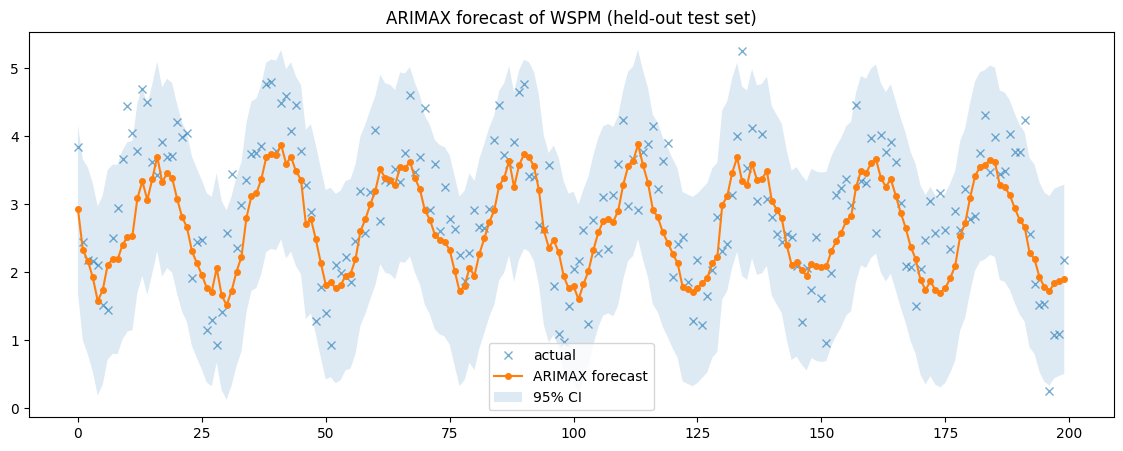

ARIMAX  MSE: 0.4991
Baseline MSE (no exog): 5.7494
Improvement: 91.3%


In [11]:
exog_test = X_test[X_selected.columns] if X_selected.shape[1] else None

arimax_fc = arimax_fit.get_forecast(steps=len(y_test), exog=exog_test)
arimax_pred = arimax_fc.predicted_mean
arimax_ci = arimax_fc.conf_int(alpha=0.05)

baseline_fit = SARIMAX(y_train, order=(2, 0, 0)).fit(disp=False)
baseline_fc = baseline_fit.get_forecast(steps=len(y_test))
baseline_pred = baseline_fc.predicted_mean

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.values, "x", label="actual", alpha=0.6)
ax.plot(arimax_pred.values, "o-", label="ARIMAX forecast", markersize=4)
ax.fill_between(range(len(arimax_pred)), arimax_ci.iloc[:, 0], arimax_ci.iloc[:, 1],
                 alpha=0.15, label="95% CI")
ax.set_title("ARIMAX forecast of WSPM (held-out test set)")
ax.legend(); plt.show()

mse_arimax = mean_squared_error(y_test, arimax_pred)
mse_baseline = mean_squared_error(y_test, baseline_pred)
print(f"ARIMAX  MSE: {mse_arimax:.4f}")
print(f"Baseline MSE (no exog): {mse_baseline:.4f}")
print(f"Improvement: {100*(1 - mse_arimax/mse_baseline):.1f}%")

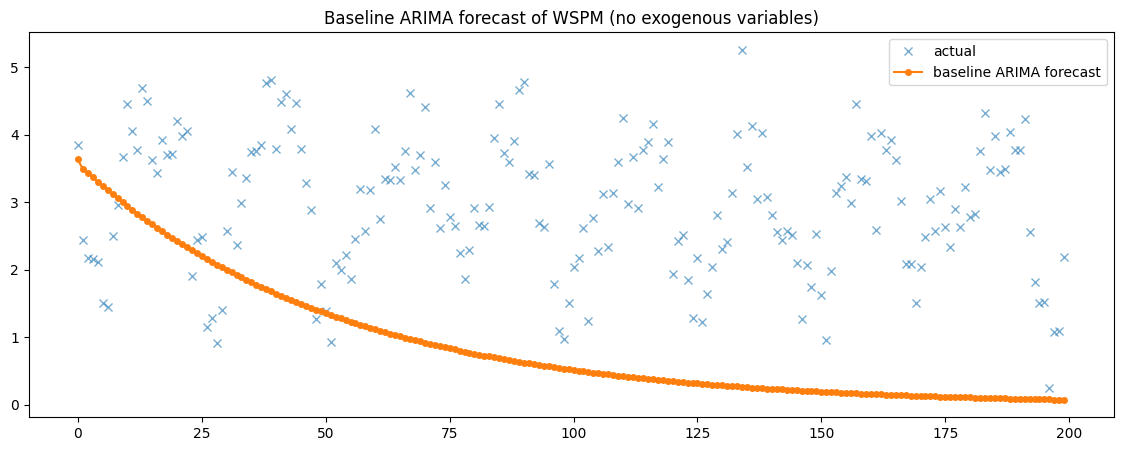

In [12]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(y_test.values, "x", label="actual", alpha=0.6)
ax.plot(baseline_pred.values, "o-", label="baseline ARIMA forecast", markersize=4, color="tab:orange")
ax.set_title("Baseline ARIMA forecast of WSPM (no exogenous variables)")
ax.legend(); plt.show()

The baseline ARIMA forecast decays quickly to the unconditional mean (a
known property of stationary ARMA models forecasting far ahead), while the
ARIMAX forecast, informed by lagged temperature/pressure/dew point, keeps
tracking the oscillation in wind speed for longer — mirroring the book's
Figures 12.6 and 12.7.

### 1.10 Extension: rolling-origin backtest sketch

A single train/test split can be misleading for a ~1000-point series. Here's
a lightweight walk-forward check: refit periodically and average the error
across several origins.

In [13]:
def rolling_origin_mse(y, X, order=(2, 0, 0), n_splits=4, test_len=40):
    scores = []
    n = len(y)
    fold_size = (n - test_len) // n_splits
    for i in range(n_splits):
        train_end = fold_size * (i + 1)
        test_end = min(train_end + test_len, n)
        if test_end <= train_end:
            continue
        y_tr, y_te = y.iloc[:train_end], y.iloc[train_end:test_end]
        X_tr, X_te = X.iloc[:train_end], X.iloc[train_end:test_end]
        try:
            fit = SARIMAX(y_tr, exog=X_tr, order=order,
                          enforce_stationarity=True, enforce_invertibility=True).fit(disp=False)
            pred = fit.get_forecast(steps=len(y_te), exog=X_te).predicted_mean
            scores.append(mean_squared_error(y_te, pred))
        except Exception as e:
            print("fold skipped:", e)
    return scores

scores = rolling_origin_mse(y, X_selected.reindex(columns=X_selected.columns).combine_first(X)[X_selected.columns], order=(2,0,0))
print("Per-fold MSE:", [round(s, 3) for s in scores])
print("Mean MSE across folds:", round(np.mean(scores), 4))

Per-fold MSE: [0.7, 0.337, 0.818, 0.487]
Mean MSE across folds: 0.5855


## Part 2 — VAR modeling (US macroeconomic data)

Uses `statsmodels`' built-in dataset — no download required, matching the
book's example exactly.

### 2.1 Load and prepare the data

In [14]:
data = sm.datasets.macrodata.load_pandas().data
data.sort_values(by=["year", "quarter"], inplace=True)
data["quarter"] = range(1, len(data) + 1)
data.index = data["quarter"]
data[["realcons", "realinv", "realdpi"]].head()

,realcons,realinv,realdpi
quarter,,,
1,1707.4,286.898,1886.9
2,1733.7,310.859,1919.7
3,1751.8,289.226,1916.4
4,1753.7,299.356,1931.3
5,1770.5,331.722,1955.5


### 2.2 Step 1 — visual inspection

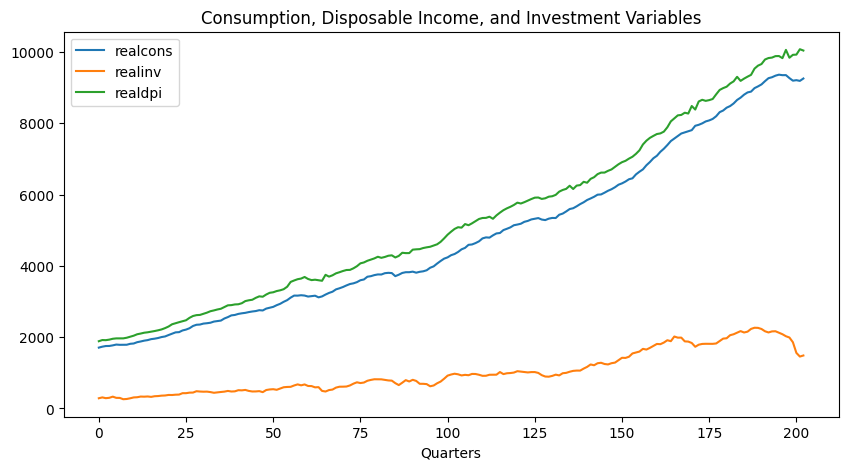

In [15]:
plt.figure(figsize=(10, 5))
plt.title("Consumption, Disposable Income, and Investment Variables")
plt.plot(data[["realcons", "realinv", "realdpi"]].values)
plt.legend(["realcons", "realinv", "realdpi"])
plt.xlabel("Quarters")
plt.show()

Strong shared upward trend across all three series — a classic
non-stationarity signature. Confirm with ADF.

### 2.3 Step 2 — stationarity tests and differencing

In [16]:
for col in ["realcons", "realinv", "realdpi"]:
    result = adfuller(data[col], autolag="AIC")
    print(f"ADF p-value for {col}: {result[1]:.4f}")

ADF p-value for realcons: 0.9977
ADF p-value for realinv: 0.6485
ADF p-value for realdpi: 1.0000


In [17]:
data_1d = pd.DataFrame()
for col in ["realcons", "realinv", "realdpi"]:
    data_1d[col] = np.diff(data[col], n=1)

for col in data_1d.columns:
    result = adfuller(data_1d[col], autolag="AIC")
    print(f"ADF p-value for differenced {col}: {result[1]:.6f}")

ADF p-value for differenced realcons: 0.000648
ADF p-value for differenced realinv: 0.000004
ADF p-value for differenced realdpi: 0.000000


### 2.4 ACF / PACF of the differenced series (order selection)

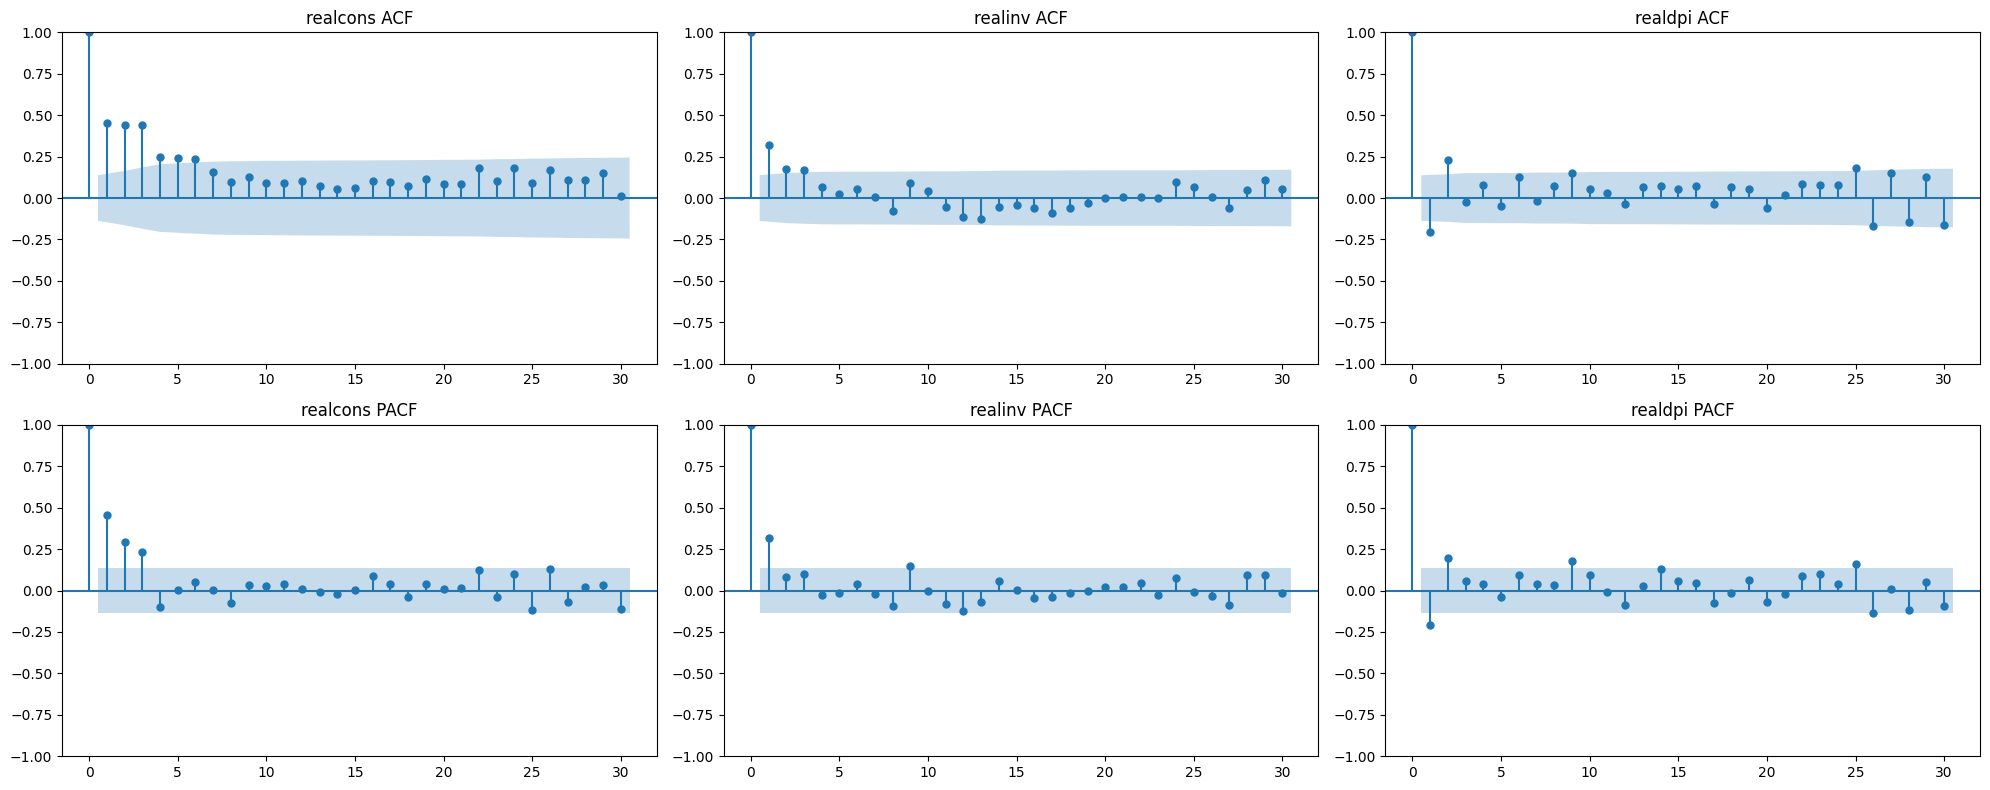

In [18]:
fig, ax = plt.subplots(2, 3, figsize=(20, 8))
for i, col in enumerate(["realcons", "realinv", "realdpi"]):
    plot_acf(data_1d[col], alpha=0.05, lags=30, ax=ax[0, i])
    ax[0, i].set_title(f"{col} ACF")
    plot_pacf(data_1d[col], alpha=0.05, lags=30, ax=ax[1, i], method="ywm")
    ax[1, i].set_title(f"{col} PACF")
plt.tight_layout(); plt.show()

### 2.5 Step 3 — cross-correlation between candidate inputs and the target

We want to forecast `realinv` (real private investment). Check its
cross-correlation with `realcons` and `realdpi`.

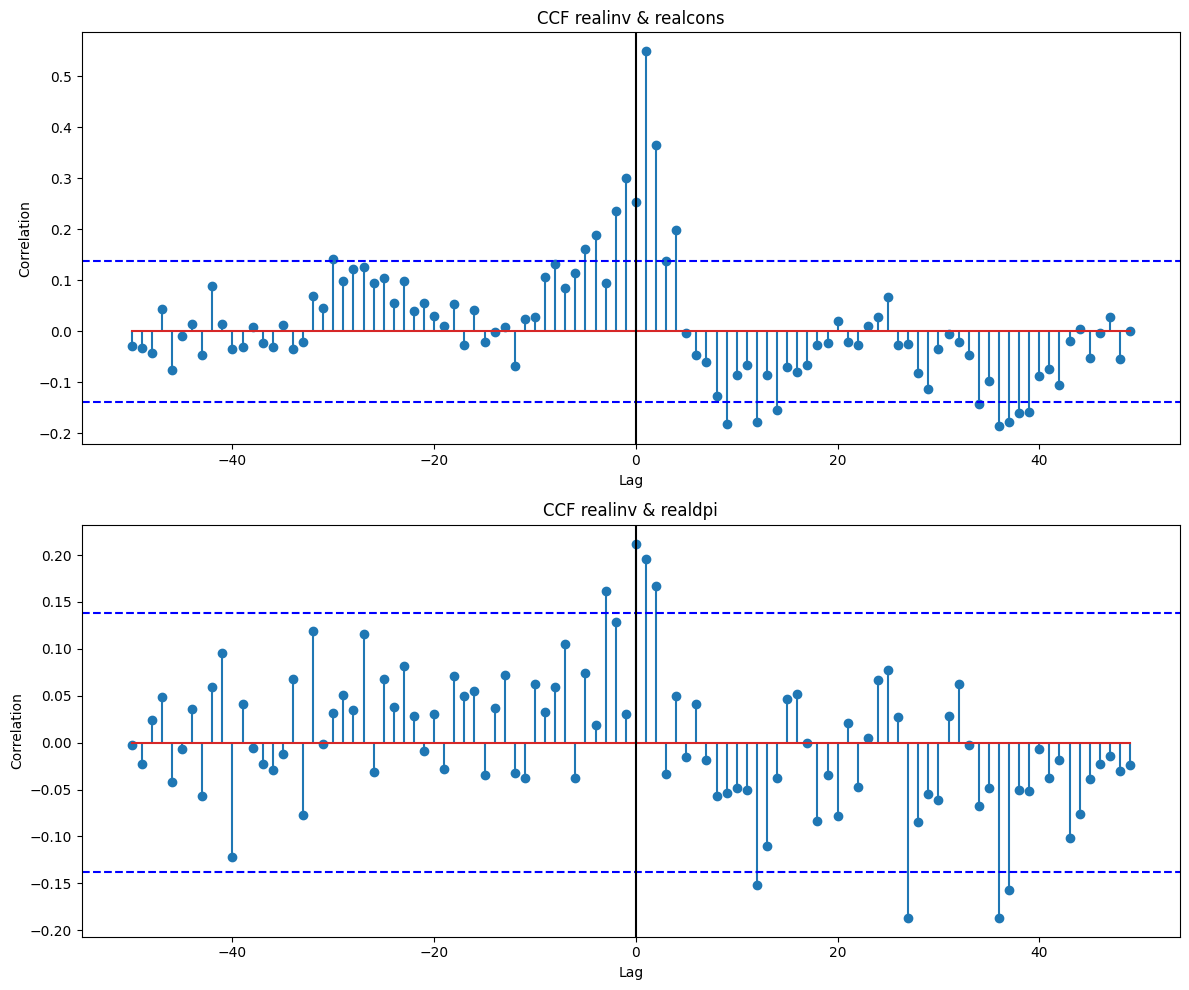

In [19]:
fig, ax = plt.subplots(2, 1, figsize=(12, 10))
plot_ccf(data_1d["realinv"], data_1d["realcons"], 50, 95, ax[0], "CCF realinv & realcons")
plot_ccf(data_1d["realinv"], data_1d["realdpi"], 50, 95, ax[1], "CCF realinv & realdpi")
plt.tight_layout(); plt.show()

`realcons` shows its strongest correlation with `realinv` just before lag
0 (a one-period lead), matching the book's finding. We could shift `realcons`
forward by one period so the peak sits at lag 0 — this reduces the required
VAR order but is *not* required for VAR to work (all lags are estimated
jointly regardless). We'll skip the shift here (as the book ultimately does
for the final model) and let the VAR order selection handle it.

### 2.6 Step 4 — grid search over VAR(p, q) order by AIC

In [20]:
results_aic = {}
for p in range(1, 4):
    for q in range(0, 2):
        try:
            model = VARMAX(data_1d, order=(p, q), trend="c",
                            enforce_stationarity=True, enforce_invertibility=True)
            fit = model.fit(disp=False)
            results_aic[(p, q)] = fit.aic
            print(f"(p,q)=({p},{q}): AIC={fit.aic:.3f}")
        except Exception as e:
            print(f"(p,q)=({p},{q}): failed ({e})")

best_order = min(results_aic, key=results_aic.get)
print("\nBest order by AIC:", best_order)

(p,q)=(1,0): AIC=6094.235


(p,q)=(1,1): AIC=6091.253


(p,q)=(2,0): AIC=6097.426


(p,q)=(2,1): AIC=6088.609


(p,q)=(3,0): AIC=6073.254


(p,q)=(3,1): AIC=6069.849

Best order by AIC: (3, 1)


### 2.7 Step 4 (cont.) — fit the selected VAR model

In [21]:
var_model = VARMAX(data_1d.reindex(columns=["realinv", "realcons", "realdpi"]),
                    order=best_order, trend="c",
                    enforce_stationarity=True, enforce_invertibility=True)
var_fit = var_model.fit(disp=False)
print(var_fit.summary())

                                   Statespace Model Results                                   
Dep. Variable:     ['realinv', 'realcons', 'realdpi']   No. Observations:                  202
Model:                                     VARMA(3,1)   Log Likelihood               -2990.156
                                          + intercept   AIC                           6070.311
Date:                                Sat, 29 Aug 2026   BIC                           6219.183
Time:                                        01:57:48   HQIC                          6130.545
Sample:                                             0                                         
                                                - 202                                         
Covariance Type:                                  opg                                         
Ljung-Box (L1) (Q):       0.01, 0.01, 0.03   Jarque-Bera (JB):   96.14, 53.59, 93.69
Prob(Q):                  0.93, 0.93, 0.85   Prob(JB):      

### 2.8 Extension: Granger causality — does `realcons` help predict `realinv`?

In [22]:
print("H0: realcons does NOT Granger-cause realinv")
gc_result = grangercausalitytests(data_1d[["realinv", "realcons"]], maxlag=4)
print()
print("H0: realdpi does NOT Granger-cause realinv")
gc_result2 = grangercausalitytests(data_1d[["realinv", "realdpi"]], maxlag=4)

H0: realcons does NOT Granger-cause realinv

H0: realdpi does NOT Granger-cause realinv


Small p-values at some lags let us reject the null and say `realcons`
(and/or `realdpi`) has statistically significant predictive content for
`realinv` beyond `realinv`'s own history — consistent with the coefficients
in the VAR summary above.

### 2.9 Step 5 — test forecast on a held-out tail

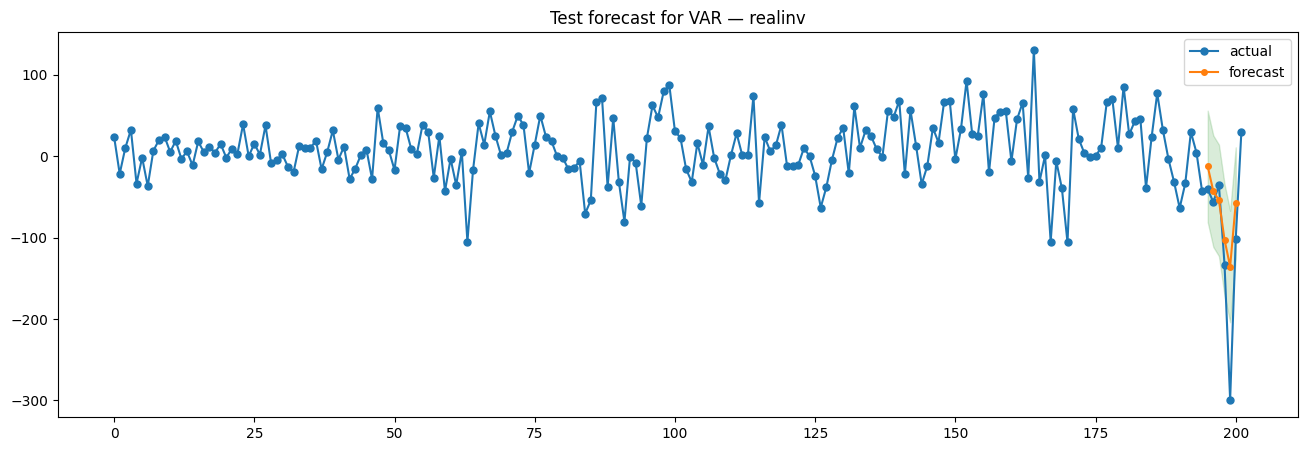

,mean,mean_se,mean_ci_lower,mean_ci_upper,realinv
195,-12.522912,34.924859,-80.974379,55.928554,-40.540
196,-43.027563,34.924859,-111.479029,25.423904,-56.368
197,-54.253724,34.924859,-122.705191,14.197743,-35.825
198,-102.566060,34.924859,-171.017527,-34.114593,-133.032
199,-135.497130,34.924859,-203.948597,-67.045664,-299.167
200,-57.592898,34.924859,-126.044365,10.858569,-101.816


In [23]:
test_start, test_end = 195, 200
df_pred = var_fit.get_prediction(start=test_start, end=test_end).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(data_1d["realinv"], marker="o", markersize=5, label="actual")
ax.plot(df_pred["mean"], marker="o", markersize=4, label="forecast")
ax.fill_between(df_pred.index, df_pred["mean_ci_lower"], df_pred["mean_ci_upper"],
                 color="g", alpha=0.15)
ax.set_title("Test forecast for VAR — realinv")
ax.legend(); plt.show()

comparison = pd.concat([df_pred, data_1d["realinv"].iloc[test_start:test_end + 1]], axis=1)
comparison

### 2.10 Step 6 — forecast beyond the observed sample

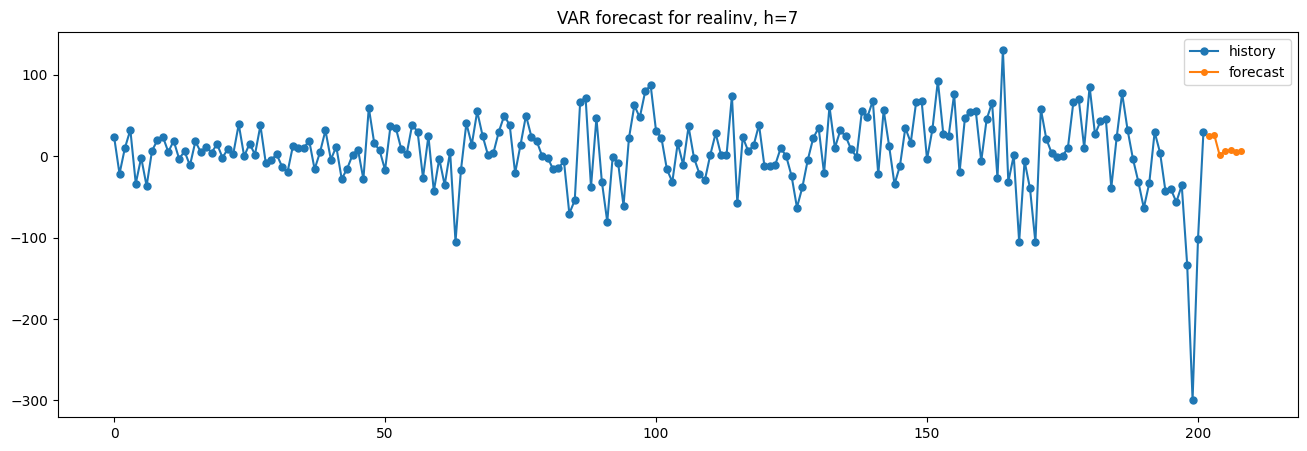

realinv,mean,mean_se,mean_ci_lower,mean_ci_upper
202,25.247980,34.924859,-43.203486,93.699447
203,26.244982,41.562359,-55.215745,107.705709
204,1.076865,45.315199,-87.739293,89.893022
205,6.209773,45.976167,-83.901858,96.321404
206,7.591982,46.717473,-83.972583,99.156547
207,5.125317,46.940828,-86.877014,97.127649
208,6.367625,47.010283,-85.770837,98.506086


In [24]:
h = 7
df_forecast = var_fit.get_prediction(start=len(data_1d), end=len(data_1d) + h - 1).summary_frame(alpha=0.05)

forecast_line = np.hstack([np.repeat(np.nan, len(data_1d)), df_forecast["mean"]])

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(data_1d["realinv"], marker="o", markersize=5, label="history")
ax.plot(forecast_line, marker="o", markersize=4, label="forecast")
ax.set_title(f"VAR forecast for realinv, h={h}")
ax.legend(); plt.show()

df_forecast

### 2.11 Extension: impulse response function — how does a shock to `realcons` propagate?

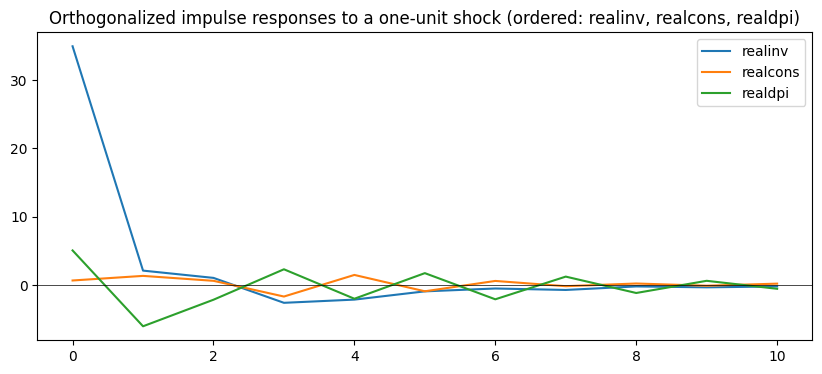

In [25]:
irf = var_fit.impulse_responses(steps=10, orthogonalized=True)
irf[["realinv", "realcons", "realdpi"]].plot(figsize=(10, 4),
    title="Orthogonalized impulse responses to a one-unit shock (ordered: realinv, realcons, realdpi)")
plt.axhline(0, color="black", lw=0.5)
plt.show()

This shows the expected response of each variable over 10 quarters
following a one-time, one-unit shock to the *first* variable in the ordering
(`realinv` here, since orthogonalized IRFs depend on variable order via a
Cholesky decomposition of the residual covariance — reordering the columns
changes the attribution of contemporaneous co-movement between shocks).

## Part 3 — Wrap-up

### 3.1 Model comparison summary

In [26]:
summary_table = pd.DataFrame({
    "Model": ["ARIMAX (wind speed)", "Baseline ARIMA (wind speed)",
              "VAR (realinv, in-sample AIC)"],
    "Metric": ["Test MSE", "Test MSE", "AIC"],
    "Value": [round(mse_arimax, 4), round(mse_baseline, 4), round(results_aic[best_order], 2)],
})
summary_table

,Model,Metric,Value
0,ARIMAX (wind speed),Test MSE,0.4991
1,Baseline ARIMA (wind speed),Test MSE,5.7494
2,"VAR (realinv, in-sample AIC)",AIC,6069.8500


### 3.2 Discussion questions

1. The wind-speed CCF plots show an *oscillating* pattern rather than a
   single sharp spike. What does that tell you about the physical process
   generating the data, and why does that make "pick the single best lag"
   a worse strategy than for a one-off leading indicator?
2. The VIF table flagged the multiple temperature lags as collinear. The
   p-value pruning loop removed some of them one at a time. Can you think of
   a scenario where that greedy removal could throw away a *pair* of jointly
   useful lags that are each individually insignificant? (Hint: think about
   what happens to p-values under strong collinearity.)
3. The VAR forecast for `realinv` gets much less accurate around the last
   observations in the book's original data — corresponding to the 2007–2009
   Great Recession. Why would a linear, constant-coefficient VAR model
   systematically struggle there, and what's one class of model that's built
   to handle this kind of regime change?
4. Suppose you only had 3 significant CCF lags between wind speed and
   temperature, but you needed a 10-step-ahead wind speed forecast. What are
   two different ways you could extend your ARIMAX forecast horizon beyond
   your smallest usable lag, and what does each one cost you in terms of
   compounding uncertainty?
5. If `realcons` and `realinv` were found to be *cointegrated* rather than
   just correlated, what would be wrong with the differencing + VAR approach
   used here, and what model would you reach for instead?
